# EDA

In [1]:
#importation des packages 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# importation des données
df = pd.read_csv(r"C:\Users\yacin\Desktop\Analyse financière entreprises\ratios_inpi_bce.csv", sep = ";")

In [3]:
df.head()

,siren,date_cloture_exercice,Chiffre_d_affaires,Marge_brute,EBE,EBIT,Resultat_net,Taux_d_endettement,Ratio_de_liquidite,Ratio_de_vetuste,...,CAF_sur_CA,Capacite_de_remboursement,Marge_EBE,Resultat_courant_avant_impots_sur_CA,Poids_BFR_exploitation_sur_CA_jours,Rotation_des_stocks_jours,Credit_clients_Jours,Credit_fournisseurs_Jours,type_bilan,confidentiality
0,493287213,2016-08-31,2078915,316815,44407,36895,35656,0.146,160.886,3.615,...,1.964,0.009,2.136,1.808,46.560,11.036,33.982,58.937,C,Public
1,493287338,2020-12-31,63890,63890,-13232,-10542,-10542,3.915,466.802,0.000,...,-16.500,0.000,-20.711,-16.500,53.084,0.000,87.051,24.323,S,Public
2,493287510,2021-10-31,0,0,0,0,53454,83.014,147.366,47.340,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,Partiellement confidentiel
3,493287734,2024-12-31,47394,47394,26046,25293,27129,213.900,188.753,70.660,...,55.750,14.102,54.956,48.681,1046.874,0.000,304.817,460.353,C,Public
4,493288013,2021-12-31,527485,527485,53558,56743,33450,217.293,272.813,NaN,...,5.738,3.311,10.153,10.757,32.516,0.000,86.666,40.709,C,Public


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6051701 entries, 0 to 6051700
Data columns (total 23 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   siren                                 int64  
 1   date_cloture_exercice                 object 
 2   Chiffre_d_affaires                    int64  
 3   Marge_brute                           int64  
 4   EBE                                   int64  
 5   EBIT                                  int64  
 6   Resultat_net                          int64  
 7   Taux_d_endettement                    float64
 8   Ratio_de_liquidite                    float64
 9   Ratio_de_vetuste                      float64
 10  Autonomie_financiere                  float64
 11  Poids_BFR_exploitation_sur_CA         float64
 12  Couverture_des_interets               float64
 13  CAF_sur_CA                            float64
 14  Capacite_de_remboursement             float64
 15  Marge_EBE      

In [5]:
cols_to_convert = [
    "Chiffre_d_affaires",
    "Marge_brute",
    "EBE",
    "EBIT",
    "Resultat_net"
]

df[cols_to_convert] = df[cols_to_convert].astype(float)


In [6]:
df["date_cloture_exercice"] = pd.to_datetime(df["date_cloture_exercice"], errors="coerce")


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6051701 entries, 0 to 6051700
Data columns (total 23 columns):
 #   Column                                Dtype         
---  ------                                -----         
 0   siren                                 int64         
 1   date_cloture_exercice                 datetime64[ns]
 2   Chiffre_d_affaires                    float64       
 3   Marge_brute                           float64       
 4   EBE                                   float64       
 5   EBIT                                  float64       
 6   Resultat_net                          float64       
 7   Taux_d_endettement                    float64       
 8   Ratio_de_liquidite                    float64       
 9   Ratio_de_vetuste                      float64       
 10  Autonomie_financiere                  float64       
 11  Poids_BFR_exploitation_sur_CA         float64       
 12  Couverture_des_interets               float64       
 13  CAF_sur_CA  

In [8]:
df.isna().sum()

siren                                         0
date_cloture_exercice                         0
Chiffre_d_affaires                            0
Marge_brute                                   0
EBE                                           0
EBIT                                          0
Resultat_net                                  0
Taux_d_endettement                         4383
Ratio_de_liquidite                        96008
Ratio_de_vetuste                        1223429
Autonomie_financiere                       2383
Poids_BFR_exploitation_sur_CA           2105628
Couverture_des_interets                 1415158
CAF_sur_CA                              2100644
Capacite_de_remboursement               1412867
Marge_EBE                               2098440
Resultat_courant_avant_impots_sur_CA    2098440
Poids_BFR_exploitation_sur_CA_jours     2105628
Rotation_des_stocks_jours               2105628
Credit_clients_Jours                    1960220
Credit_fournisseurs_Jours               

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["date_cloture_exercice"].min(), df["date_cloture_exercice"].max()

(Timestamp('1919-09-30 00:00:00'), Timestamp('2026-02-06 00:00:00'))

In [11]:
df["Taux_d_endettement"].describe()

# Comptage des valeurs extrêmes
extreme_neg = (df["Taux_d_endettement"] < -10).sum()
extreme_pos = (df["Taux_d_endettement"] > 10).sum()
extreme_100 = (df["Taux_d_endettement"] > 100).sum()
extreme_1000 = (df["Taux_d_endettement"] > 1000).sum()

extreme_neg, extreme_pos, extreme_100, extreme_1000


(np.int64(627431), np.int64(3401303), np.int64(1390865), np.int64(217270))

On garde uniquement les ratios raisonnables :

-10 \leq \text{Taux_d_endettement} \leq 10
Cela élimine :

les entreprises en faillite

les bilans aberrants

les erreurs de saisie

In [12]:
df_clean = df[
    (df["Taux_d_endettement"] >= -10) &
    (df["Taux_d_endettement"] <= 10)
]


In [13]:
df_clean.shape


(2018584, 23)

In [14]:
df_clean["Taux_d_endettement"].describe()


count    2.018584e+06
mean     1.784971e+00
std      2.904906e+00
min     -1.000000e+01
25%      0.000000e+00
50%      1.660000e-01
75%      3.014000e+00
max      1.000000e+01
Name: Taux_d_endettement, dtype: float64

## Dataviz

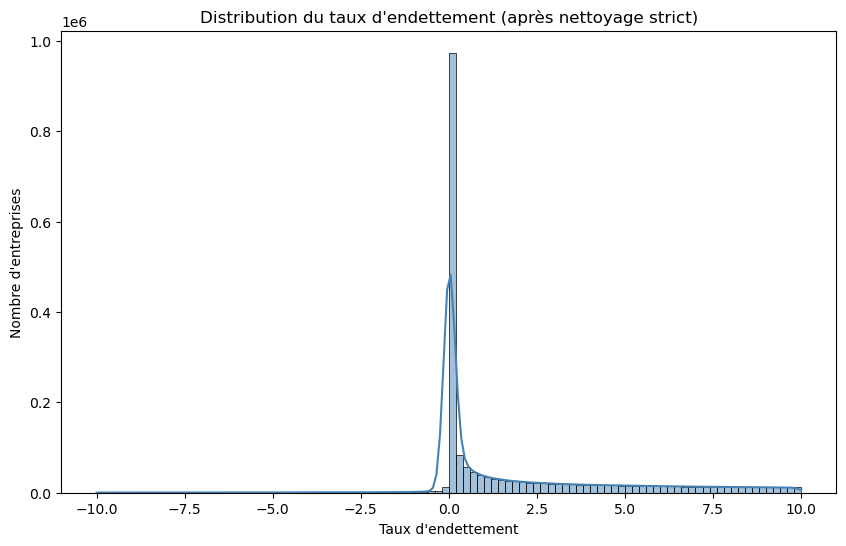

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean["Taux_d_endettement"], bins=100, kde=True, color="steelblue")
plt.title("Distribution du taux d'endettement (après nettoyage strict)")
plt.xlabel("Taux d'endettement")
plt.ylabel("Nombre d'entreprises")
plt.show()


In [16]:
# 1. Un pic massif autour de 0

# une grande partie des entreprises françaises ont très peu de dettes financières
# beaucoup de micro et petites structures fonctionnent quasi sans emprunt
# les bilans simplifiés tirent la distribution vers 0

# 2. Une décroissance progressive jusqu’à 10.
# des entreprises plus endettées

# des PME/ETI qui utilisent le levier financier

# des secteurs naturellement plus capitalistiques (industrie, transport, énergie)



# 3. Une petite queue vers la gauche
# On voit quelques valeurs négatives (jusqu’à –10), ce qui correspond à :

# capitaux propres légèrement négatifs

# entreprises en difficulté mais pas aberrantes

# bilans fragiles mais réalistes

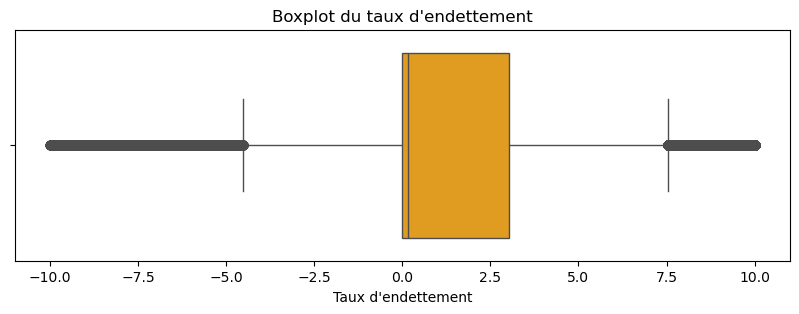

In [17]:
plt.figure(figsize=(10,3))
sns.boxplot(x=df_clean["Taux_d_endettement"], color="orange")
plt.title("Boxplot du taux d'endettement")
plt.xlabel("Taux d'endettement")
plt.show()


In [18]:
#Nous voyons que la plupart des entreprises ont très peu de dettes (médiane très basse),
#  que la dispersion reste raisonnable (la majorité est entre 0 et 2,5), 
# et que seules quelques entreprises sont atypiques mais encore réalistes (points proches de –10 et +10).

### 1. Etape suivante : Analyse temporelle du taux d’endettement

In [19]:
# On extrait l'année depuis la date de clôture
df_clean["annee"] = df_clean["date_cloture_exercice"].dt.year


C:\Users\yacin\AppData\Local\Temp\ipykernel_31852\2956556716.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["annee"] = df_clean["date_cloture_exercice"].dt.year


In [20]:
# On calcule la médiane du taux d'endettement pour chaque année
df_year = df_clean.groupby("annee")["Taux_d_endettement"].median()

# On affiche le résultat pour vérifier
df_year


annee
1919    6.3590
2006    0.0000
2009    0.0000
2010    0.2955
2011    0.0915
2012    0.0000
2013    0.0000
2014    0.0000
2015    0.0000
2016    0.1360
2017    0.2790
2018    0.2670
2019    0.2490
2020    0.1450
2021    0.1520
2022    0.1540
2023    0.1010
2024    0.1070
2025    0.4530
2026    0.0000
Name: Taux_d_endettement, dtype: float64

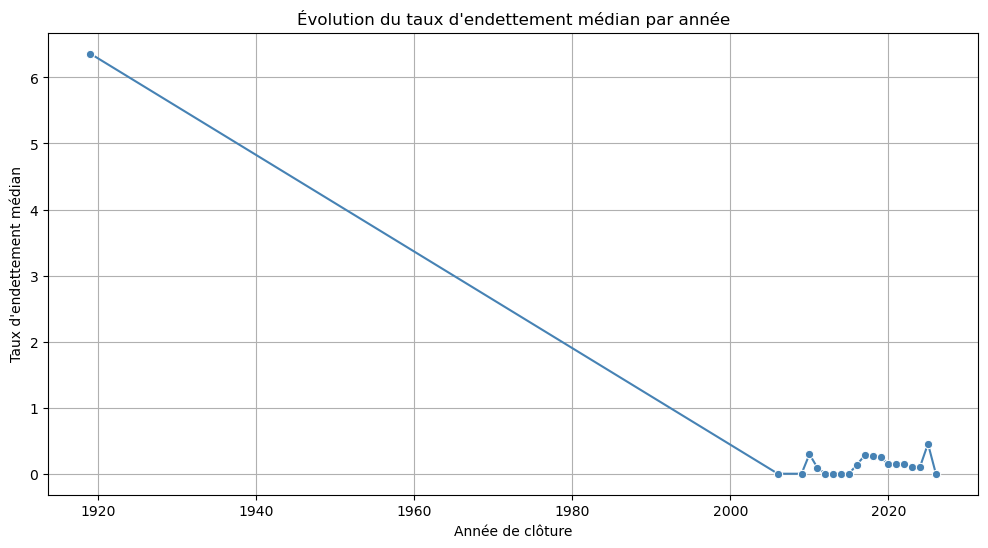

In [21]:
# 3. Visualiser l’évolution d'endettement dans le temps
# On trace l'évolution du taux d'endettement médian par année
plt.figure(figsize=(12,6))
sns.lineplot(x=df_year.index, y=df_year.values, marker="o", color="steelblue")

plt.title("Évolution du taux d'endettement médian par année")
plt.xlabel("Année de clôture")
plt.ylabel("Taux d'endettement médian")
plt.grid(True)

plt.show()


In [22]:
# Avant 2000, les données sont instables.
# Après 2000, l’endettement médian est très faible et très stable.
# Les entreprises françaises restent globalement peu endettées dans le temps.

### 2. Calculer la médiane du taux d’endettement par type de bilan

In [23]:
# On regarde les types de bilans présents dans la base
df_clean["type_bilan"].value_counts()


type_bilan
C    1473090
S     539999
K       5495
Name: count, dtype: int64

In [24]:
# On calcule la médiane du taux d'endettement pour chaque type de bilan
df_bilan = (
    df_clean
    .groupby("type_bilan")["Taux_d_endettement"]
    .median()
    .sort_values()
)

# On affiche pour vérifier
df_bilan


type_bilan
K    0.000
S    0.000
C    0.312
Name: Taux_d_endettement, dtype: float64

C:\Users\yacin\AppData\Local\Temp\ipykernel_31852\544001207.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


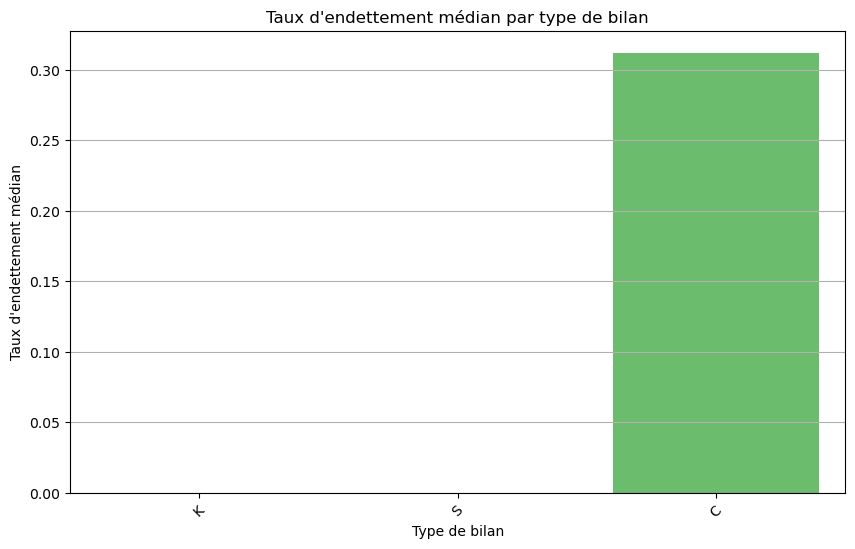

In [25]:
plt.figure(figsize=(10,6))

# On trace un barplot pour comparer les catégories
sns.barplot(
    x=df_bilan.index,
    y=df_bilan.values,
    palette="viridis"
)

plt.title("Taux d'endettement médian par type de bilan")
plt.xlabel("Type de bilan")
plt.ylabel("Taux d'endettement médian")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()


In [26]:
# es petites entreprises (K et S) n’ont quasiment pas de dettes,
# alors que les entreprises plus structurées (C) 
# utilisent l’endettement de manière normale et maîtrisée.

###  Analyse de CAF_sur_CA

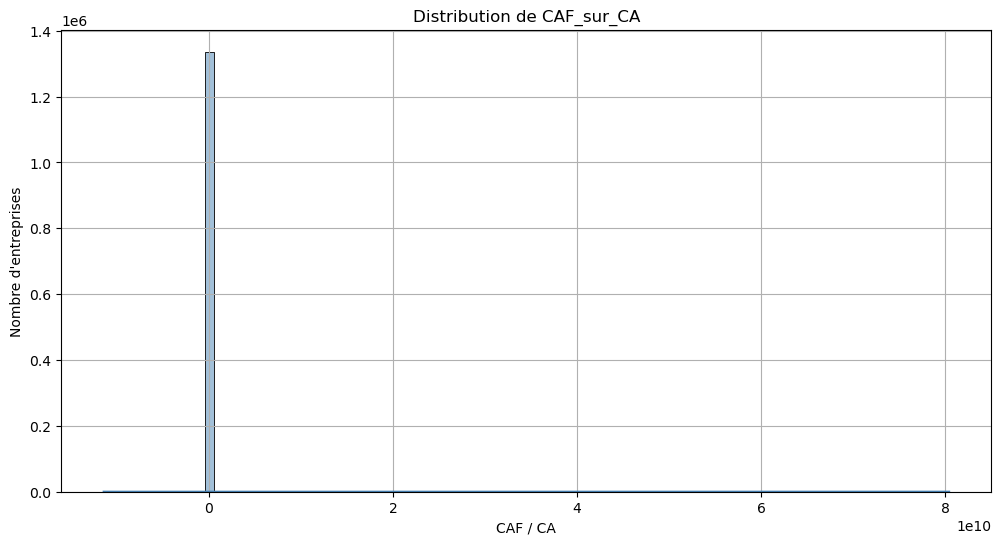

In [27]:
# 1. Histogramme de CAF_sur_CA
# Histogramme de CAF_sur_CA
plt.figure(figsize=(12,6))
sns.histplot(df_clean["CAF_sur_CA"], bins=100, kde=True, color="steelblue")

plt.title("Distribution de CAF_sur_CA")
plt.xlabel("CAF / CA")
plt.ylabel("Nombre d'entreprises")
plt.grid(True)

plt.show()


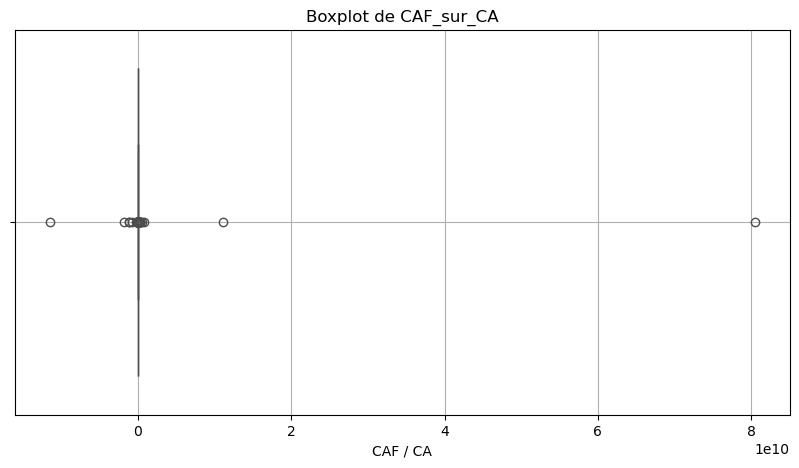

In [28]:
# Boxplot de CAF_sur_CA
plt.figure(figsize=(10,5))
sns.boxplot(x=df_clean["CAF_sur_CA"], color="orange")

plt.title("Boxplot de CAF_sur_CA")
plt.xlabel("CAF / CA")
plt.grid(True)

plt.show()


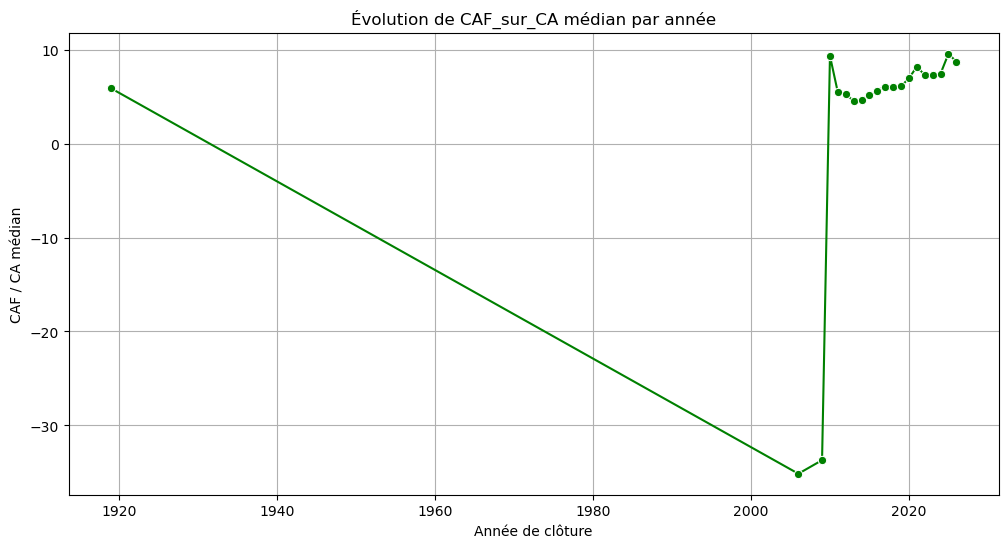

In [29]:
# On calcule la médiane par année
df_caf_year = df_clean.groupby("annee")["CAF_sur_CA"].median()

# Visualisation
plt.figure(figsize=(12,6))
sns.lineplot(x=df_caf_year.index, y=df_caf_year.values, marker="o", color="green")

plt.title("Évolution de CAF_sur_CA médian par année")
plt.xlabel("Année de clôture")
plt.ylabel("CAF / CA médian")
plt.grid(True)

plt.show()


In [30]:
df_caf = df_clean[df_clean["annee"] >= 2000].copy()


In [31]:
df_caf = df_caf[(df_caf["CAF_sur_CA"] >= -1) & (df_caf["CAF_sur_CA"] <= 1)]


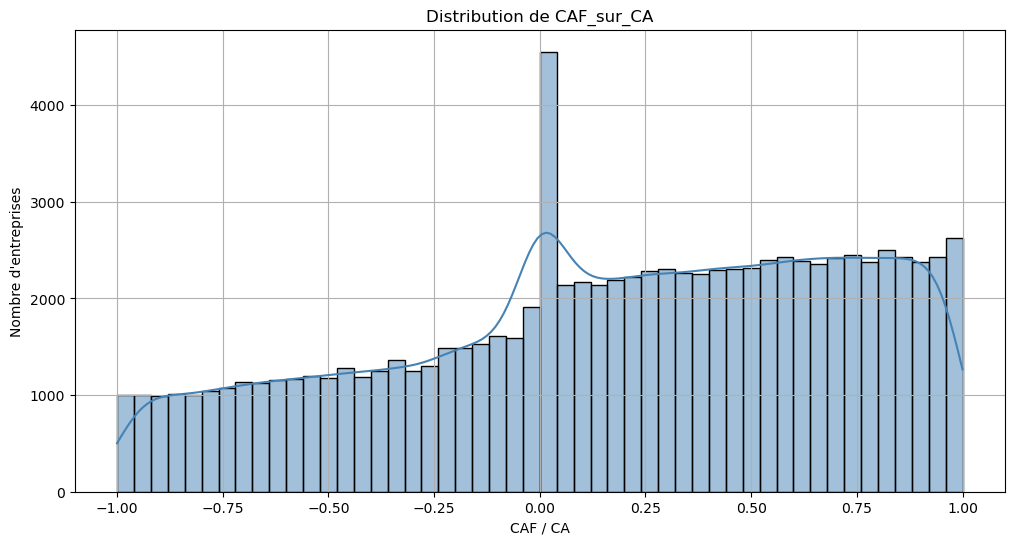

In [32]:
plt.figure(figsize=(12,6))
sns.histplot(df_caf["CAF_sur_CA"], bins=50, kde=True, color="steelblue")
plt.title("Distribution de CAF_sur_CA")
plt.xlabel("CAF / CA")
plt.ylabel("Nombre d'entreprises")
plt.grid(True)
plt.show()


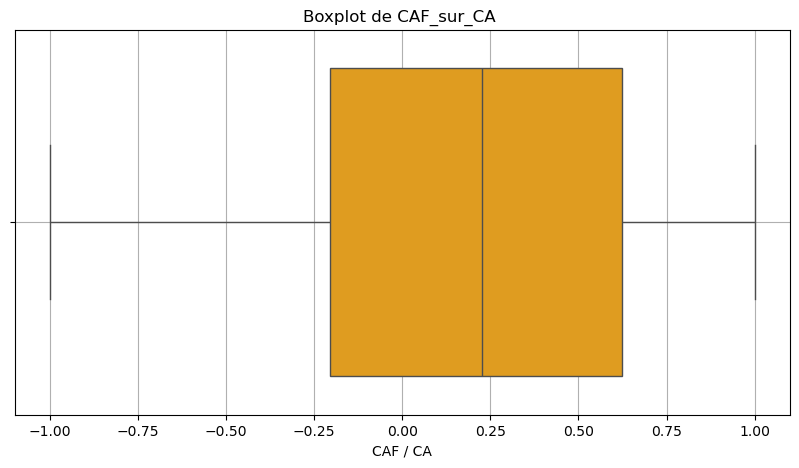

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_caf["CAF_sur_CA"], color="orange")
plt.title("Boxplot de CAF_sur_CA ")
plt.xlabel("CAF / CA")
plt.grid(True)
plt.show()


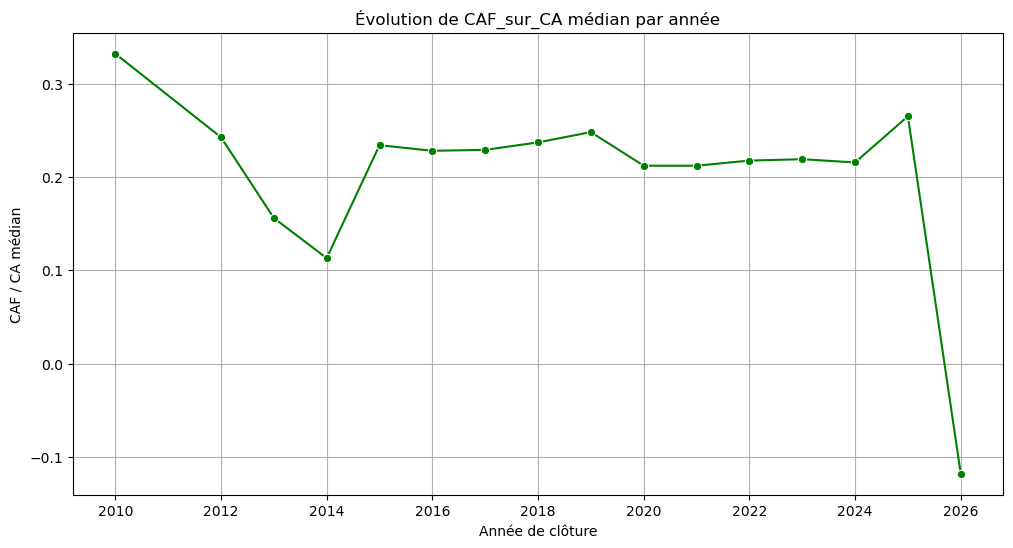

In [34]:
df_caf_year = df_caf.groupby("annee")["CAF_sur_CA"].median()

plt.figure(figsize=(12,6))
sns.lineplot(x=df_caf_year.index, y=df_caf_year.values, marker="o", color="green")
plt.title("Évolution de CAF_sur_CA médian par année")
plt.xlabel("Année de clôture")
plt.ylabel("CAF / CA médian")
plt.grid(True)
plt.show()


In [35]:
#La majorité des entreprises ont une CAF/CA faible mais positive.

#La médiane tourne autour de 20–25%, ce qui est cohérent.

#La dynamique temporelle est logique et économique.

#Les données 2026 sont incomplètes, donc on ignore la chute.

### Est‑ce que les entreprises plus endettées génèrent plus ou moins de cash ?  

In [36]:
#On garde uniquement les données nettoyées qu’on a déjà filtrées :

"""années ≥ 2000

CAF_sur_CA entre -1 et 1

Taux d’endettement déjà nettoyé"""

'années ≥ 2000\n\nCAF_sur_CA entre -1 et 1\n\nTaux d’endettement déjà nettoyé'

In [37]:
df_cross = df_clean[
    (df_clean["annee"] >= 2000) &
    (df_clean["CAF_sur_CA"].between(-1, 1)) &
    (df_clean["Taux_d_endettement"].between(0, 5))  # sécurité
].copy()


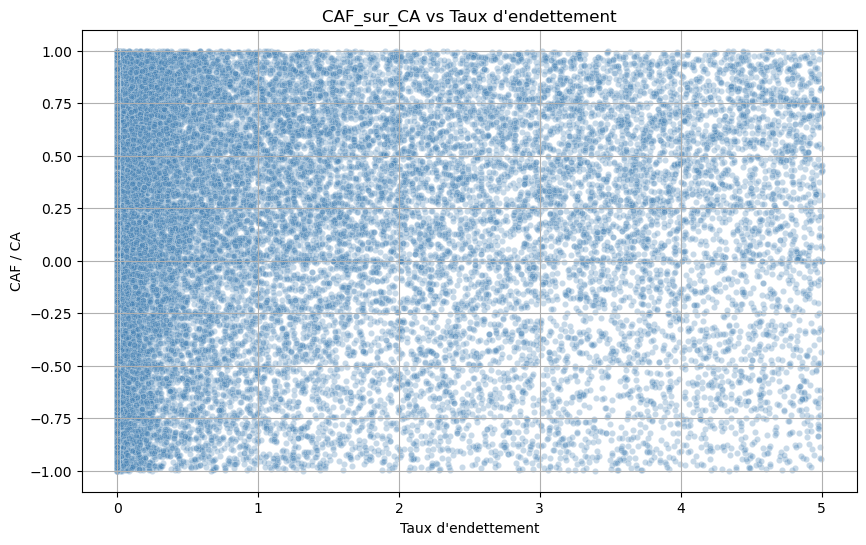

In [38]:
# 2. Scatterplot : CAF_sur_CA vs Taux d’endettement
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_cross.sample(50000),  # on échantillonne pour lisibilité
    x="Taux_d_endettement",
    y="CAF_sur_CA",
    alpha=0.3,
    s=20,
    color="steelblue"
)

plt.title("CAF_sur_CA vs Taux d'endettement")
plt.xlabel("Taux d'endettement")
plt.ylabel("CAF / CA")
plt.grid(True)

plt.show()


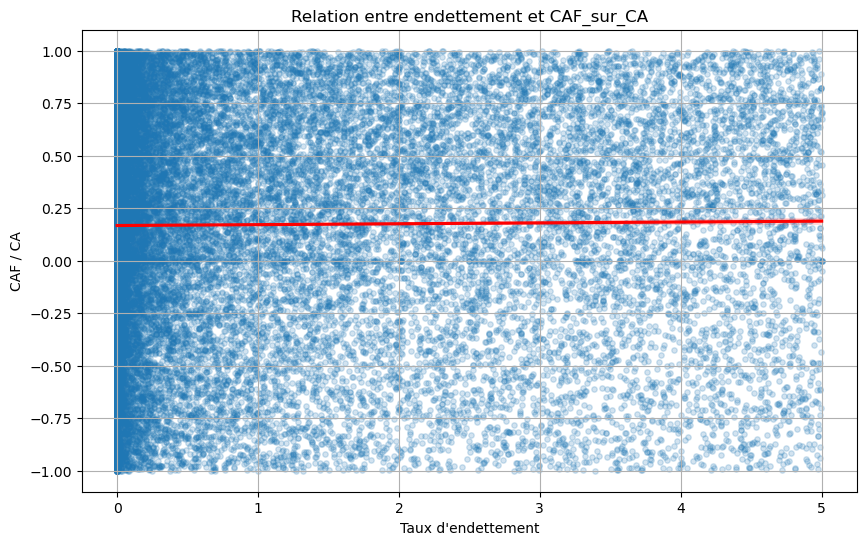

In [39]:
#3. Ajouter une droite de tendance (régression linéaire)
plt.figure(figsize=(10,6))

sns.regplot(
    data=df_cross.sample(50000),
    x="Taux_d_endettement",
    y="CAF_sur_CA",
    scatter_kws={'alpha':0.2, 's':15},
    line_kws={'color':'red'}
)

plt.title("Relation entre endettement et CAF_sur_CA")
plt.xlabel("Taux d'endettement")
plt.ylabel("CAF / CA")
plt.grid(True)

plt.show()


In [40]:
# 4. Calculer la corrélation
df_cross[["Taux_d_endettement", "CAF_sur_CA"]].corr()


,Taux_d_endettement,CAF_sur_CA
Taux_d_endettement,1.000000,0.012765
CAF_sur_CA,0.012765,1.000000


In [41]:
# ) Les entreprises très endettées ne génèrent pas plus de cash
# La corrélation est tellement faible qu’elle est statistiquement insignifiante.

# L’endettement n’explique pas la rentabilité opérationnelle.
# Une entreprise peut être très rentable et peu endettée.
# Une autre peut être très endettée et peu rentable.
# Et tout l’inverse existe aussi.

## 3-  Autonomie financière
 
Il mesure la solidité financière :
Capitaux propres / Total du passif

On peut analyser :

distribution

boxplot

évolution dans le temps

comparaison par type de bilan

corrélation avec CAF/CA

corrélation avec endettement

##### “Alors qu’est‑ce qui explique la solidité d’une entreprise ?”
 L’autonomie financière.

C’est le ratio qui dit si une entreprise est solide, indépendante, capable d’encaisser les chocs.

#### 1- Distribution de l’autonomie financière

In [42]:
# L’autonomie financière est un ratio compris entre 0 et 1 dans 95% des cas.
# Mais certaines entreprises peuvent dépasser 1 (capitaux propres > total passif), donc on garde une marge.

# On filtre entre 0 et 2 pour rester propre.
df_auto = df_clean[
    (df_clean["annee"] >= 2000) &
    (df_clean["Autonomie_financiere"].between(0, 2))
].copy()


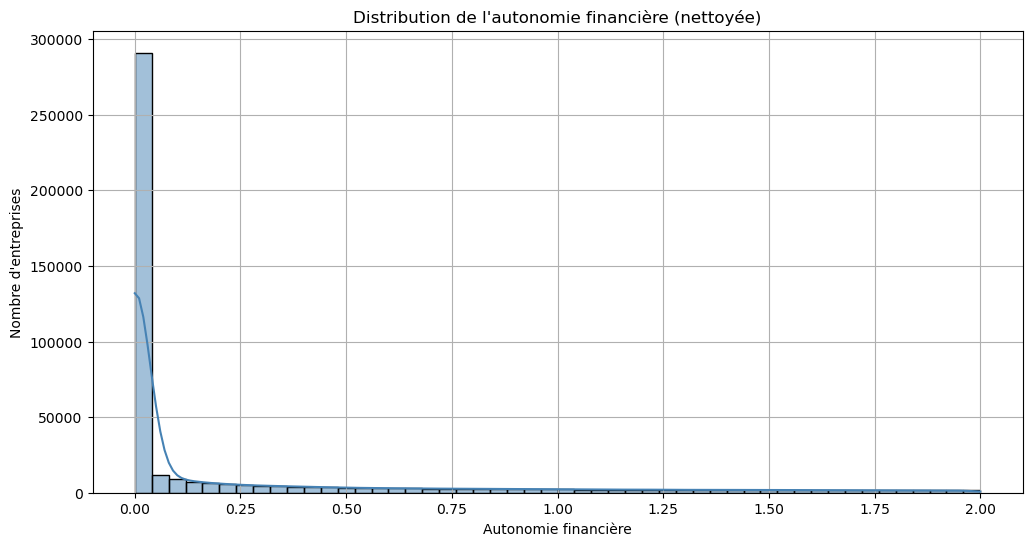

In [43]:
plt.figure(figsize=(12,6))
sns.histplot(df_auto["Autonomie_financiere"], bins=50, kde=True, color="steelblue")
plt.title("Distribution de l'autonomie financière (nettoyée)")
plt.xlabel("Autonomie financière")
plt.ylabel("Nombre d'entreprises")
plt.grid(True)
plt.show()


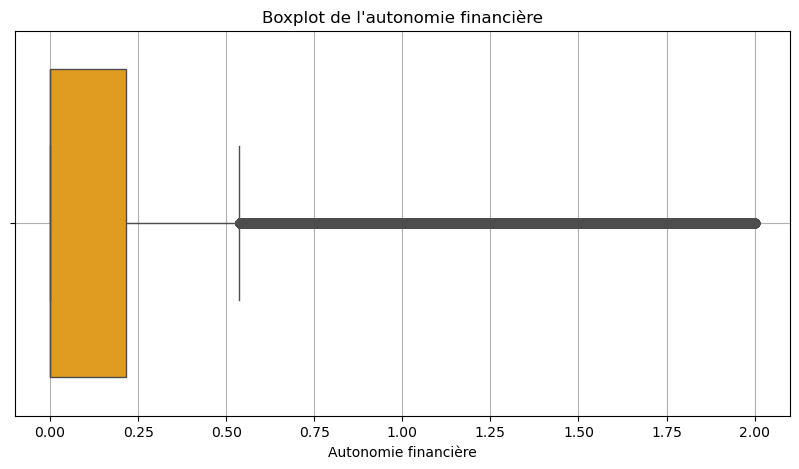

In [45]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_auto["Autonomie_financiere"], color="orange")
plt.title("Boxplot de l'autonomie financière")
plt.xlabel("Autonomie financière")
plt.grid(True)
plt.show()


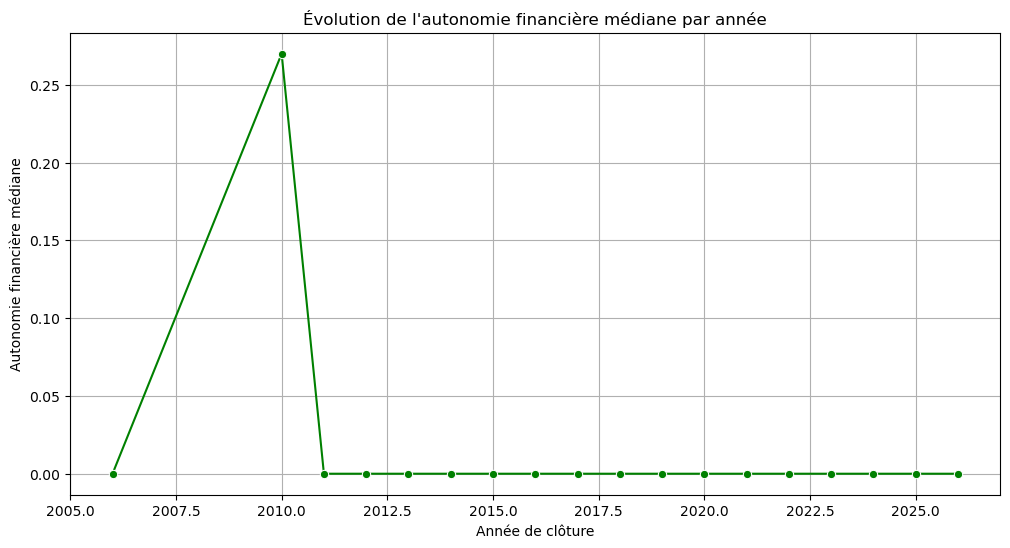

In [46]:
df_auto_year = df_auto.groupby("annee")["Autonomie_financiere"].median()

plt.figure(figsize=(12,6))
sns.lineplot(x=df_auto_year.index, y=df_auto_year.values, marker="o", color="green")
plt.title("Évolution de l'autonomie financière médiane par année")
plt.xlabel("Année de clôture")
plt.ylabel("Autonomie financière médiane")
plt.grid(True)
plt.show()


#### Relation Autonomie Financière ↔ CAF/CA

In [47]:
df_auto[["Autonomie_financiere", "CAF_sur_CA"]].corr()


,Autonomie_financiere,CAF_sur_CA
Autonomie_financiere,1.000000,-0.000952
CAF_sur_CA,-0.000952,1.000000
